In [ ]:
python_workflow = {1: 'Collect Data', 
                   2: 'Build Model', 
                   3: 'Training',
                   4: 'Evaluation and Testing', 
                   5: 'Saving and Load Model',
                   6: 'Putting it all Together'
                   }

In [3]:
python_workflow

{1: 'Collect Data',
 2: 'Build Model',
 3: 'Training',
 4: 'Evaluation and Testing',
 5: 'Saving and Load Model',
 6: 'Putting it all Together'}

In [1]:
import torch 
from torch import nn 
import matplotlib.pyplot as plt 

In [4]:
torch.__version__

'2.9.0+cu126'

### LINEAR REGRESSION 
- (f(x) = WX + b)

In [14]:
weight = 0.5
bias = 0.3
X = torch.arange(start=1, end= 100, step=5)
X, X.shape

(tensor([ 1,  6, 11, 16, 21, 26, 31, 36, 41, 46, 51, 56, 61, 66, 71, 76, 81, 86,
         91, 96]),
 torch.Size([20]))

In [15]:
X = X.unsqueeze(dim=1)
X, X.shape

(tensor([[ 1],
         [ 6],
         [11],
         [16],
         [21],
         [26],
         [31],
         [36],
         [41],
         [46],
         [51],
         [56],
         [61],
         [66],
         [71],
         [76],
         [81],
         [86],
         [91],
         [96]]),
 torch.Size([20, 1]))

In [18]:
# linear regression 
y = weight*X + bias
y

tensor([[ 0.8000],
        [ 3.3000],
        [ 5.8000],
        [ 8.3000],
        [10.8000],
        [13.3000],
        [15.8000],
        [18.3000],
        [20.8000],
        [23.3000],
        [25.8000],
        [28.3000],
        [30.8000],
        [33.3000],
        [35.8000],
        [38.3000],
        [40.8000],
        [43.3000],
        [45.8000],
        [48.3000]])

### Splitting data into train and test (80/20)

In [25]:
# # Using Sklearn
# import sklearn
# from sklearn.model_selection import train_test_split

# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
# X_train.shape, y_train.shape

In [26]:
train_split = int(0.8* len(X))
X_train, y_train = X[: train_split], y[: train_split]
X_test, y_test = X[train_split :], y[train_split :]
X_train.shape, y_train.shape

(torch.Size([16, 1]), torch.Size([16, 1]))

### Visualizing Data 

In [29]:
# Using Matplotlib 
def plot_predictions(train_data = X_train, 
                     train_label = y_train, 
                     test_data = X_test, 
                     test_label = y_test, 
                     prediction = None
                     ):
    
    '''
    Plot Train, Test Data and also predicted data if inputed
    '''
    
    plt.figure(figsize=(10,7))
    
    # plot train data 
    plt.scatter(train_data, train_label, c='b', marker="o", label="Training data")
    
    # plot test data 
    plt.scatter(test_data, test_label, c='g', marker="*", label="Testing data")
    
    # if prediction is available
    if prediction is not None: 
        plt.scatter(test_data, prediction, c='r', marker="@", label="Predicted data")
        
    plt.legend(prop={'size':14})

    

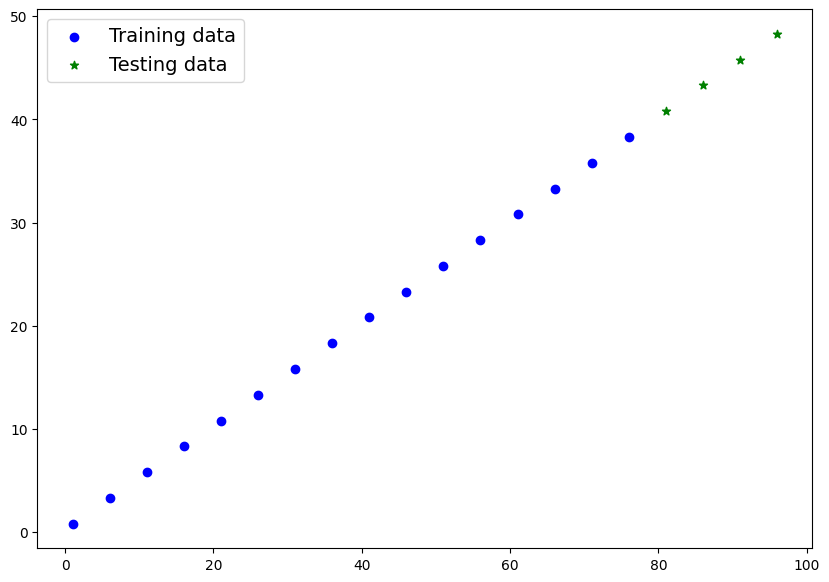

In [30]:
plot_predictions()

### Build Model 

In [31]:
# linear regression 
class LinearRegressionModel(nn.Module): 
    def __init__(self):
        super.__init__()
        
        self.weights = nn.Parameter(torch.randn(1, requires_grad=True, dtype=torch.float32))
        
        self.bias = nn.Parameter(torch.randn(1, requires_grad=True, dtype=torch.float32))
        
        # forward method 
        def forward(self, x:torch.Tensor) -> torch.Tensor:
            return self.weights * x + self.bias
            
        
        